### The Core Equation
$$\hat{y} = W \cdot X + B$$
#### Breaking Down Each Component

#### Ŷ (y-hat) — Model Prediction

The model's estimate for the target
"What the model thinks the answer is"
Rarely equals true value (y) exactly

#### W (Weight) — The Slope

Controls the steepness of the line
Shows how much y changes when X increases by 1 unit
In house pricing: "price increase per sqft"
Units: [output units / input units]

#### B (Bias) — The Intercept

The value of y when X = 0
Shifts the entire line up or down
In house pricing: "base price when size = 0"
Units: [same as y]

### Extended: Multivariate Linear Regression
When multiple features exist:
$$\hat{y} = W_1 \cdot X_1 + W_2 \cdot X_2 + ... + W_n \cdot X_n + B$$


Example with house features: $$\hat{\text{price}} = W_{\text{size}} \cdot \text{size} + W_{\text{rooms}} \cdot \text{rooms} + W_{\text{age}} \cdot \text{age} + B$$
Vector Form (Compact Notation)
$$\hat{y} = \mathbf{W}^T \mathbf{X} + B$$
Where W and X are vectors

In [1]:
import numpy as np 

In [2]:
# simple univariate case

def predict(x,w,b):
    return w * x + b

### 1. Single Prediction

In [3]:
w = 150
b = 50000
x_single = 2000
y_single = predict(x_single, w, b)
print(f"House of {x_single} sqft : ${y_single}")

House of 2000 sqft : $350000


### 2. Multiple Predictions at once Vetorized

In [4]:
x_batch = np.array([600, 800 ,1000 , 1200, 1400])
y_batch = predict(x_batch,w,b)
print(f"y batch: {y_batch}")

for x, y in zip(x_batch,y_batch):
    print(f"x: {x}, y: ${y}")

y batch: [140000 170000 200000 230000 260000]
x: 600, y: $140000
x: 800, y: $170000
x: 1000, y: $200000
x: 1200, y: $230000
x: 1400, y: $260000


### 3. MultiVariance case

In [5]:
x_multi = np.array([
    [2000, 3, 10],
    [1500, 2, 5],
    [3000, 4, 1]
])

w_multi = np.array([150,2000,-500])
b_multi = 50000

y_multi = x_multi @ w_multi + b_multi

print("\n Multivariance predictions")

for i , (x,y) in enumerate(zip(x_multi, y_multi)):
    print(f" sample {i+1}: {x} -> ${y}")





 Multivariance predictions
 sample 1: [2000    3   10] -> $351000
 sample 2: [1500    2    5] -> $276500
 sample 3: [3000    4    1] -> $507500


### Visualization: Impact of W and B

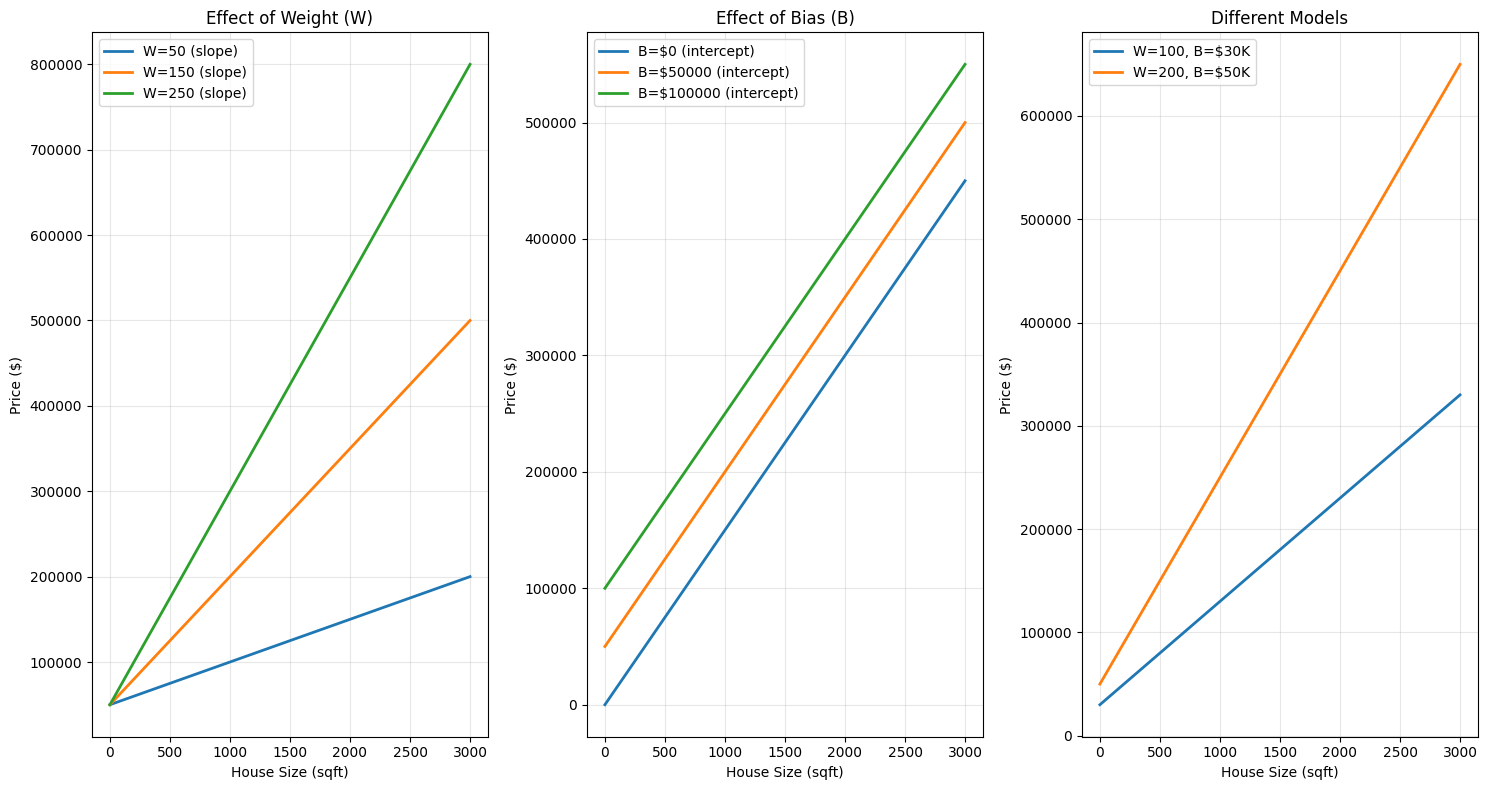

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = np.linspace(0, 3000, 100)

# Different W values (different slopes)
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Plot 1: Varying W

ax1 = axes[0]
for W in [50, 150, 250]:
    y = W * X + 50000
    ax1.plot(X, y, label=f"W={W} (slope)", linewidth=2)

ax1.set_xlabel("House Size (sqft)")
ax1.set_ylabel("Price ($)")
ax1.set_title("Effect of Weight (W)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Varying B

ax2 = axes[1]
for B in [0, 50000, 100000]:
    y = 150 * X + B
    ax2.plot(X, y, label=f"B=${B} (intercept)", linewidth=2)

ax2.set_xlabel("House Size (sqft)")
ax2.set_ylabel("Price ($)")
ax2.set_title("Effect of Bias (B)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Comparison

ax3 = axes[2]
y1 = 100 * X + 30000
y2 = 200 * X + 50000
ax3.plot(X, y1, label="W=100, B=$30K", linewidth=2)
ax3.plot(X, y2, label="W=200, B=$50K", linewidth=2)
ax3.set_xlabel("House Size (sqft)")
ax3.set_ylabel("Price ($)")
ax3.set_title("Different Models")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visual Output Description:
# Plot 1: Steeper lines = higher W = more sensitive to size changes
# Plot 2: Higher lines = higher B = higher base price
# Plot 3: Different combinations create different lines

=== Learned Parameters ===
Weight (W): 126.79
Bias (B): 102142.86

=== Manual Calculation ===
Weight (W): -0.00
Bias (B): 254285.71

=== Understanding W ===
If you increase house size by 100 sqft:
  Price increases by: $12678.57
If you increase house size by 500 sqft:
  Price increases by: $63392.86


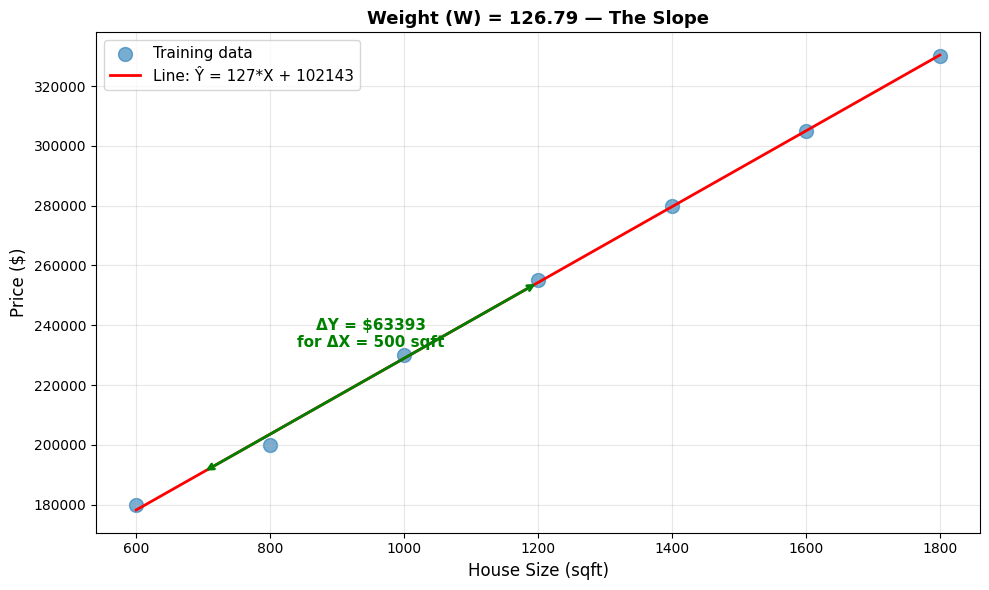

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated house data
X = np.array([600, 800, 1000, 1200, 1400, 1600, 1800]).reshape(-1, 1)
y = np.array([180000, 200000, 230000, 255000, 280000, 305000, 330000])

# Method 1: Using sklearn (automatic)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
W_learned = model.coef_[0]
B_learned = model.intercept_

print("=== Learned Parameters ===")
print(f"Weight (W): {W_learned:.2f}")
print(f"Bias (B): {B_learned:.2f}")
# Output:
# Weight (W): 150.00
# Bias (B): 50000.00

# Method 2: Manual calculation using least squares formula
X_mean = np.mean(X)
y_mean = np.mean(y)

numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean) ** 2)

W_manual = numerator / denominator
B_manual = y_mean - W_manual * X_mean

print("\n=== Manual Calculation ===")
print(f"Weight (W): {W_manual:.2f}")
print(f"Bias (B): {B_manual:.2f}")
# Output: Same as above

# Method 3: Understanding W through scatter and line
print("\n=== Understanding W ===")
print(f"If you increase house size by 100 sqft:")
print(f"  Price increases by: ${W_learned * 100:.2f}")
print(f"If you increase house size by 500 sqft:")
print(f"  Price increases by: ${W_learned * 500:.2f}")

# Visualization: W as slope
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, alpha=0.6, label="Training data")

# Plot regression line
y_pred = model.predict(X)
plt.plot(X, y_pred, 'r-', linewidth=2, label=f"Line: Ŷ = {W_learned:.0f}*X + {B_learned:.0f}")

# Show slope visually
# Pick two points on the line
x1, x2 = 700, 1200
y1_line = W_learned * x1 + B_learned
y2_line = W_learned * x2 + B_learned

plt.annotate('', xy=(x2, y2_line), xytext=(x1, y1_line),
        arrowprops=dict(arrowstyle='<->', color='green', lw=2))
plt.text((x1+x2)/2, (y1_line+y2_line)/2 + 10000, 
        f'ΔY = ${W_learned*(x2-x1):.0f}\nfor ΔX = {x2-x1} sqft',
        fontsize=11, ha='center', color='green', weight='bold')

plt.xlabel("House Size (sqft)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.title(f"Weight (W) = {W_learned:.2f} — The Slope", fontsize=13, weight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visual Output:
# Price ($)
#   400K │              •
#   350K │          •
#   300K │       •         ──→ Rise
#   250K │    •        ←─ Run
#   200K │ •
#   150K │
#        └─────────────────── Size (sqft)
#        600  1000  1400  1800